# 四数据集声学分布分析 (Four-Dataset Acoustic Distribution Analysis)

**交付背景**：这是导师在 2026-06-29 / 2026-07-13 / 2026-07-23 三次会议中反复要求、但此前一直缺失的交付项（duration / sampling rate / device / estimated SNR / energy / PSD / frequency profile 的系统分析），也是独立审计 `docs/audits/2026-07-23_research_audit.ipynb` 中 **E6 决策 gate** 的第一版实现。

**目的**：量化 ICBHI 2017、SPRSound BioCAS2022、HF_Lung_V1、KAUH/Fraiwan 四个数据集之间的**低层声学域移 (acoustic domain shift)**，并回答审计的一个关键证伪问题——*跨数据集迁移的强弱，是否可能被数据集/设备层面的声学"指纹"（shortcut）解释*。

**方法**：
- 逐 recording 的声学描述子由 `dataset/script/acoustic_distribution.py` 只读计算（13,704 个 recording，0 错误），身份/设备/split/类别解析复用 `publication_curation_audit.py` 的 canonical 逻辑。
- 幅度/SNR 在**原生采样率**下计算；频谱描述子在统一 **4 kHz 分析率**下计算（四数据集原生均 ≥4 kHz，呼吸诊断能量 <2 kHz，故对关注频段无损），保证跨数据集频谱在同一频率栅格上比较。
- `snr_proxy_db` 是能量分位数代理（响帧 dB − 静帧 dB），**是代理不是标定测量**。

**只读边界**：不修改任何 raw audio；输出落在 git-ignored 的 `result/acoustic_distribution/`，本 notebook 与 `.py` 引擎为提交的可复现产物。

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "result").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
AD = ROOT / "result" / "acoustic_distribution"
FIG = AD / "figures"; FIG.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(AD / "recording_features.csv")
ORDER = ["ICBHI", "SPRSound", "HF_Lung", "KAUH"]
PAL = {"ICBHI": "#4C72B0", "SPRSound": "#DD8452", "HF_Lung": "#55A868", "KAUH": "#C44E52"}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25, "axes.axisbelow": True})
print("recordings:", len(df), "| per dataset:", df.dataset.value_counts().reindex(ORDER).to_dict())

recordings: 13704 | per dataset: {'ICBHI': 920, 'SPRSound': 2683, 'HF_Lung': 9765, 'KAUH': 336}


## 1. 数据集规模、采样率、设备、时长、类别构成

第一层就已暴露强异质性：采样率与设备在数据集之间几乎不重叠。

In [2]:
# --- summary tables ---
sr_comp = pd.crosstab(df.dataset, df.native_sr).reindex(ORDER).fillna(0).astype(int)
dev_comp = df.groupby("dataset").device.value_counts().unstack(fill_value=0).reindex(ORDER).fillna(0).astype(int)
dur = df.groupby("dataset").duration_s.agg(["count","min","median","mean","max"]).reindex(ORDER).round(2)
sr_comp.to_csv(AD/"samplerate_composition.csv"); dev_comp.to_csv(AD/"device_composition.csv")
print("native sample-rate composition (recordings):\n", sr_comp.to_string(), "\n")
print("device composition:\n", dev_comp.to_string(), "\n")
print("duration (s):\n", dur.to_string())

native sample-rate composition (recordings):
 native_sr  4000   8000   10000  44100
dataset                              
ICBHI         90      0      6    824
SPRSound       0   2683      0      0
HF_Lung     9765      0      0      0
KAUH         336      0      0      0 

device composition:
 device    AKGC417L  HF_Type-1  Litt3200  LittC2SE  Littmann3200  Meditron  Yunting_II
dataset                                                                              
ICBHI          646          0        60        87             0       127           0
SPRSound         0          0         0         0             0         0        2683
HF_Lung          0       5261         0         0          4504         0           0
KAUH             0          0         0         0           336         0           0 

duration (s):
           count    min  median   mean    max
dataset                                     
ICBHI       920   7.86   20.00  21.49  86.20
SPRSound   2683   0.30    9.22  10.

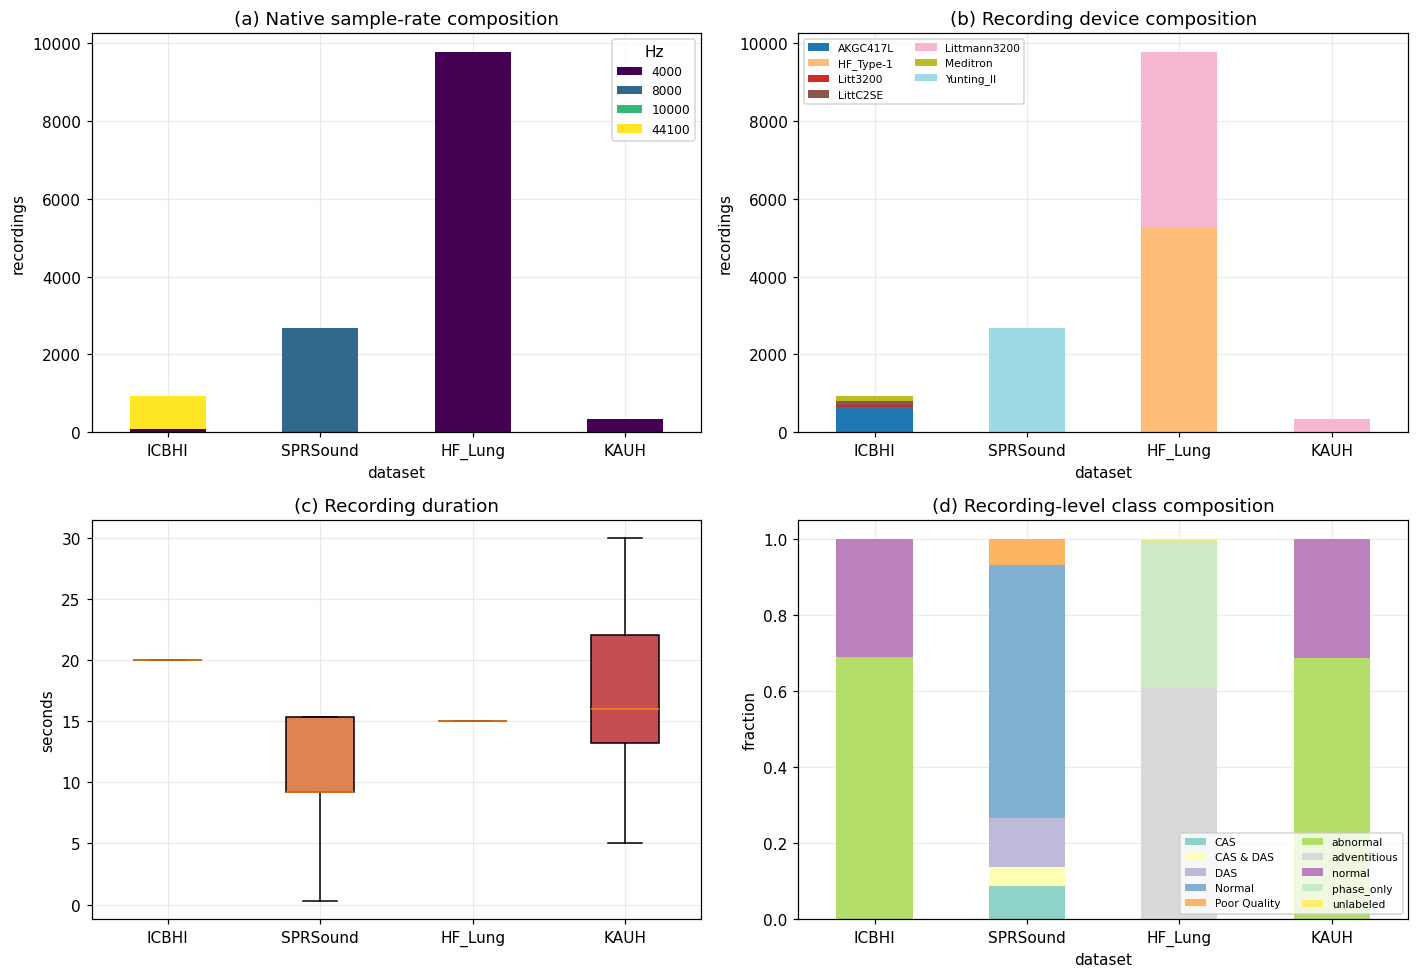

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))
# (a) sample rate
sr_comp.plot(kind="bar", stacked=True, ax=ax[0,0], colormap="viridis")
ax[0,0].set_title("(a) Native sample-rate composition"); ax[0,0].set_ylabel("recordings"); ax[0,0].tick_params(axis='x', rotation=0)
ax[0,0].legend(title="Hz", fontsize=8)
# (b) device
dev_comp.plot(kind="bar", stacked=True, ax=ax[0,1], colormap="tab20")
ax[0,1].set_title("(b) Recording device composition"); ax[0,1].set_ylabel("recordings"); ax[0,1].tick_params(axis='x', rotation=0)
ax[0,1].legend(fontsize=7, ncol=2)
# (c) duration
data = [df[df.dataset==d].duration_s.values for d in ORDER]
bp = ax[1,0].boxplot(data, labels=ORDER, patch_artist=True, showfliers=False)
for patch, d in zip(bp['boxes'], ORDER): patch.set_facecolor(PAL[d])
ax[1,0].set_title("(c) Recording duration"); ax[1,0].set_ylabel("seconds")
# (d) recording-class composition (normalized)
cls = df.groupby("dataset").recording_class.value_counts(normalize=True).unstack(fill_value=0).reindex(ORDER)
cls.plot(kind="bar", stacked=True, ax=ax[1,1], colormap="Set3")
ax[1,1].set_title("(d) Recording-level class composition"); ax[1,1].set_ylabel("fraction"); ax[1,1].tick_params(axis='x', rotation=0)
ax[1,1].legend(fontsize=7, ncol=2, loc="lower right")
plt.tight_layout(); plt.savefig(FIG/"fig1_dataset_overview.png", bbox_inches="tight"); plt.show()

**读数**：ICBHI 混合 44.1k/10k/4k 且含 **4 种设备**（AKGC417L / Meditron / LittC2SE / Litt3200）；SPRSound 全 8 kHz 单设备（Yunting II）；HF_Lung 全 4 kHz 双设备；KAUH 全 4 kHz 单设备（Littmann 3200）。**采样率与设备本身就是数据集近乎无损的判别特征**——这是后面 shortcut 分析的起点。

## 2. 幅度 / 响度 / SNR 代理

响度（dBFS）跨数据集相差约 26 dB，是最强的低层混杂之一。

median amplitude/SNR descriptors:
             dbfs  crest_db  snr_proxy_db    zcr  clip_frac
dataset                                                   
ICBHI    -16.836    13.995        12.986  0.022        0.0
SPRSound -43.196    31.517        15.382  0.079        0.0
HF_Lung  -33.006    22.380        15.264  0.112        0.0
KAUH     -20.404    20.409        12.916  0.014        0.0


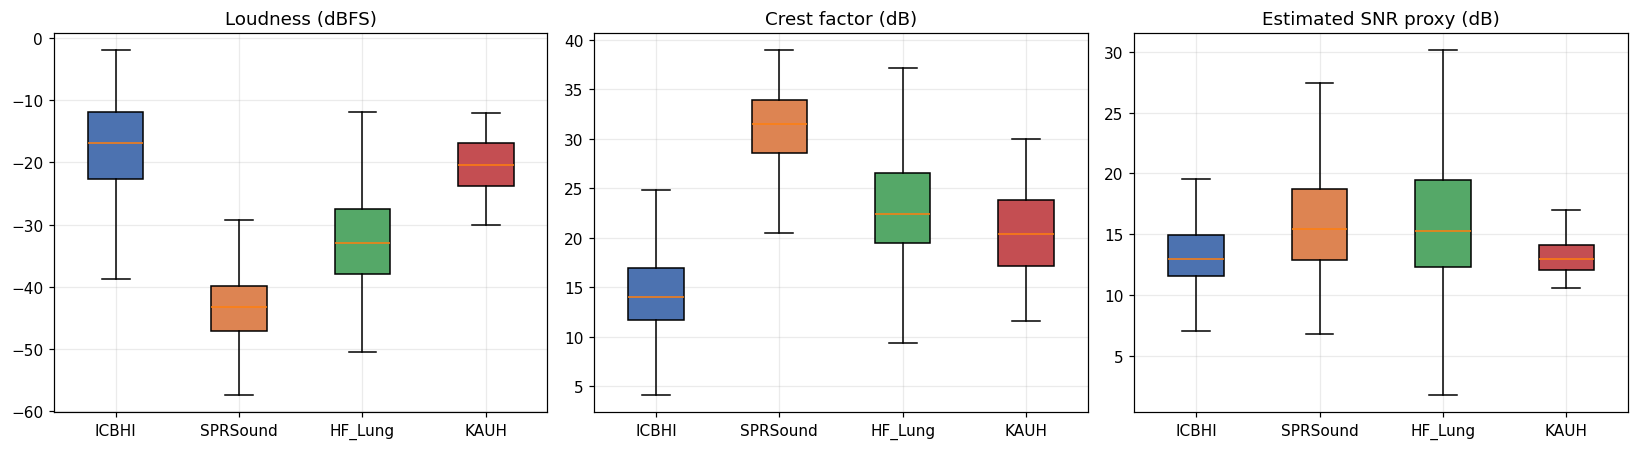

In [4]:
amp_cols = ["dbfs","crest_db","snr_proxy_db","zcr","clip_frac"]
amp = df.groupby("dataset")[amp_cols].median().reindex(ORDER).round(3)
print("median amplitude/SNR descriptors:\n", amp.to_string())

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for a, col, title in zip(ax, ["dbfs","crest_db","snr_proxy_db"],
                         ["Loudness (dBFS)","Crest factor (dB)","Estimated SNR proxy (dB)"]):
    data = [df[df.dataset==d][col].values for d in ORDER]
    bp = a.boxplot(data, labels=ORDER, patch_artist=True, showfliers=False)
    for patch, d in zip(bp['boxes'], ORDER): patch.set_facecolor(PAL[d])
    a.set_title(title)
plt.tight_layout(); plt.savefig(FIG/"fig2_amplitude_snr.png", bbox_inches="tight"); plt.show()

**读数**：ICBHI（中位 −16.8 dBFS）与 KAUH（−20.4）明显更响，HF（−33.0）居中，SPRSound（−43.2）最安静。crest factor 与之呼应。SNR 代理四者中位 12.9–15.4 dB，差异相对温和——说明**主要域移在响度与频谱形状，而非信噪比**。

## 3. 频谱形状 / PSD 频带能量分布

这是最能揭示"数据集指纹"的一层：raw 能量的频带分布在四数据集之间几乎正交。

median spectral descriptors:
           centroid_hz  bandwidth_hz  rolloff85_hz  flatness
dataset                                                    
ICBHI           29.74         38.88         46.88      0.00
SPRSound       171.59         77.14        246.09      0.00
HF_Lung        148.20        157.22        218.75      0.03
KAUH            23.22         22.66         35.16      0.00 

mean band-energy fraction:
           band_0_100  band_100_250  band_250_500  band_500_1000  band_1000_2000
dataset                                                                        
ICBHI          0.934         0.051         0.008          0.004           0.002
SPRSound       0.117         0.688         0.190          0.005           0.000
HF_Lung        0.510         0.296         0.104          0.064           0.027
KAUH           0.984         0.011         0.003          0.001           0.000


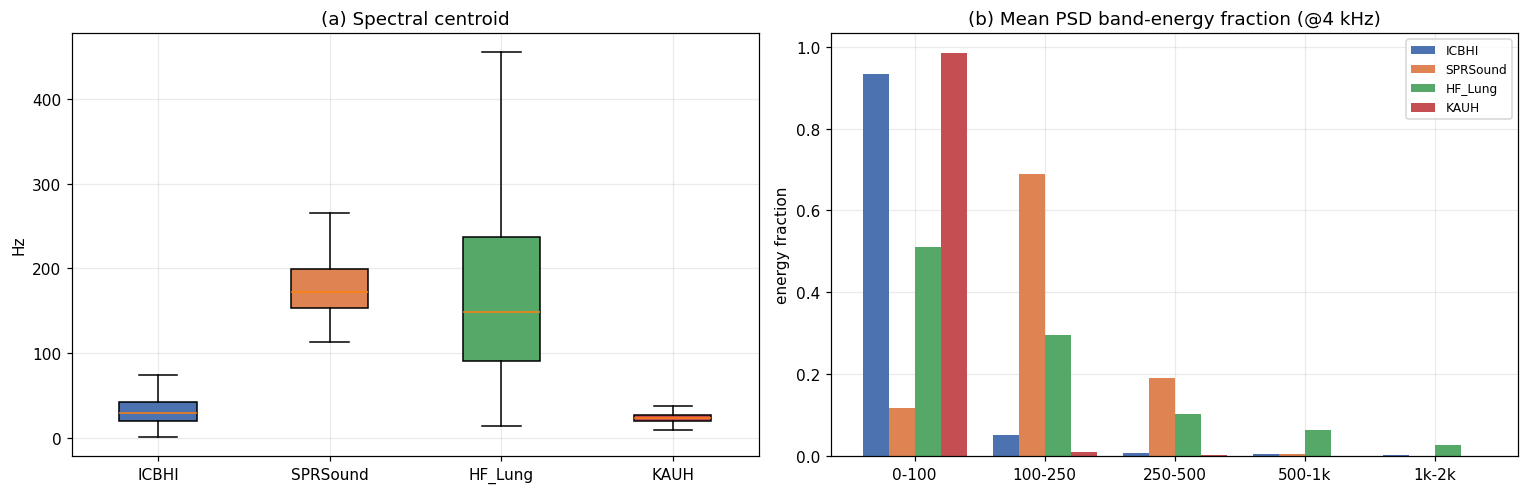

In [5]:
spec_cols = ["centroid_hz","bandwidth_hz","rolloff85_hz","flatness"]
band_cols = ["band_0_100","band_100_250","band_250_500","band_500_1000","band_1000_2000"]
spec = df.groupby("dataset")[spec_cols].median().reindex(ORDER).round(2)
bands = df.groupby("dataset")[band_cols].mean().reindex(ORDER).round(3)
spec.join(bands).to_csv(AD/"spectral_summary.csv")
print("median spectral descriptors:\n", spec.to_string(), "\n")
print("mean band-energy fraction:\n", bands.to_string())

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
# centroid box
data = [df[df.dataset==d].centroid_hz.values for d in ORDER]
bp = ax[0].boxplot(data, labels=ORDER, patch_artist=True, showfliers=False)
for patch, d in zip(bp['boxes'], ORDER): patch.set_facecolor(PAL[d])
ax[0].set_title("(a) Spectral centroid"); ax[0].set_ylabel("Hz")
# band-energy profile grouped bar
x = np.arange(len(band_cols)); w = 0.2
for i, d in enumerate(ORDER):
    ax[1].bar(x + (i-1.5)*w, bands.loc[d].values, w, label=d, color=PAL[d])
ax[1].set_xticks(x); ax[1].set_xticklabels(["0-100","100-250","250-500","500-1k","1k-2k"])
ax[1].set_title("(b) Mean PSD band-energy fraction (@4 kHz)"); ax[1].set_ylabel("energy fraction"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG/"fig3_spectral_bands.png", bbox_inches="tight"); plt.show()

**读数**：raw 能量频带分布高度数据集特异——ICBHI/KAUH >96% 能量 <100 Hz（接触式听诊、心音/低频主导），SPRSound 71% 集中在 100–250 Hz，HF 分布最宽（<100 Hz 占 51%、100–250 占 26%）。呼吸诊断方法通常会带通滤波(≈50–2000 Hz)，因此这些 raw 分布主要反映**采集/设备特性**，而非病理内容——正是跨数据集 shortcut 的物理基础。

## 4. 跨数据集域移可视化 + 数据集身份可分性探针 (E6)

**核心问题**：仅用手工低层声学特征，能否轻易判别一个 recording 来自哪个数据集？若能——则任意 encoder 都可利用数据集身份作 shortcut，跨数据集"迁移"数字必须谨慎解读。

Dataset-ID linear probe (balanced 336/dataset, 5-fold CV): balanced accuracy = 0.9353
chance = 0.25



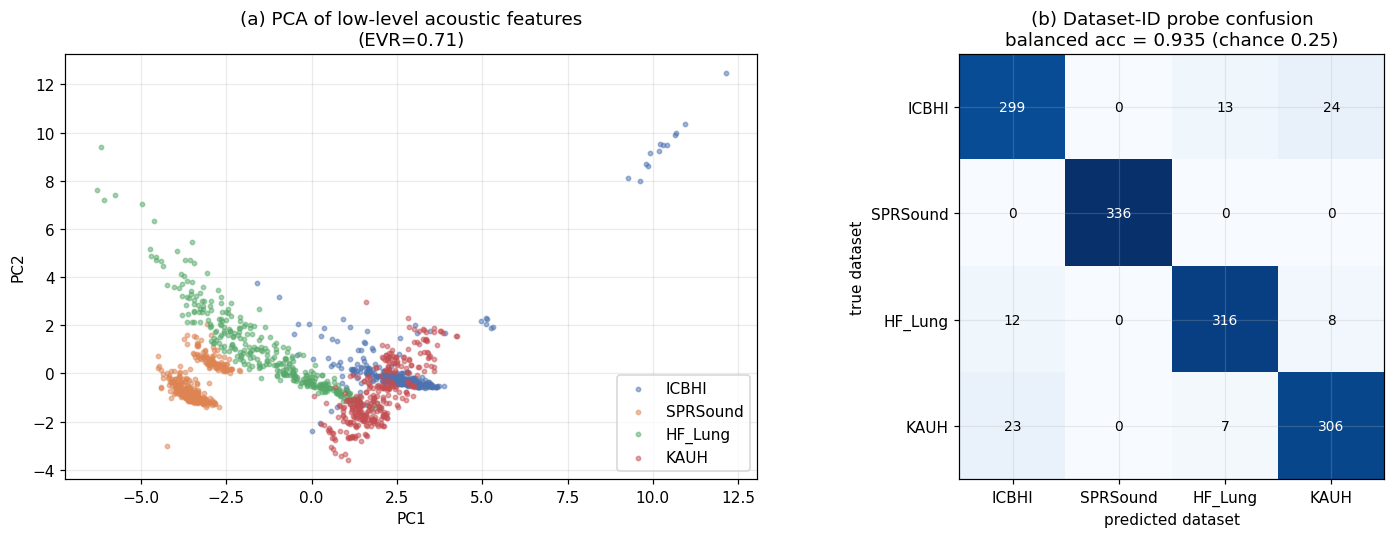

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

feat = ["duration_s","dbfs","crest_db","snr_proxy_db","centroid_hz","bandwidth_hz",
        "rolloff85_hz","flatness","zcr"] + band_cols
X = df[feat].replace([np.inf,-np.inf], np.nan).fillna(df[feat].median())
Xs = StandardScaler().fit_transform(X)
y = df.dataset.values

# balanced subsample (min class = KAUH 336) for a fair separability probe
rng = np.random.default_rng(0)
idx = np.concatenate([rng.choice(np.where(y==d)[0], 336, replace=False) for d in ORDER])
Xb, yb = Xs[idx], y[idx]
clf = LogisticRegression(max_iter=2000, multi_class="multinomial")
pred = cross_val_predict(clf, Xb, yb, cv=5)
bacc = balanced_accuracy_score(yb, pred)
cm = confusion_matrix(yb, pred, labels=ORDER)
pd.DataFrame(cm, index=ORDER, columns=ORDER).to_csv(AD/"dataset_id_probe_confusion.csv")
print(f"Dataset-ID linear probe (balanced 336/dataset, 5-fold CV): balanced accuracy = {bacc:.4f}")
print("chance = 0.25\n")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
# PCA scatter
pca = PCA(n_components=2).fit(Xb)
Z = pca.transform(Xb)
for d in ORDER:
    m = yb==d; ax[0].scatter(Z[m,0], Z[m,1], s=8, alpha=.5, label=d, color=PAL[d])
ax[0].set_title(f"(a) PCA of low-level acoustic features\n(EVR={pca.explained_variance_ratio_[:2].sum():.2f})")
ax[0].set_xlabel("PC1"); ax[0].set_ylabel("PC2"); ax[0].legend()
# confusion heatmap
im = ax[1].imshow(cm, cmap="Blues")
ax[1].set_xticks(range(4)); ax[1].set_xticklabels(ORDER); ax[1].set_yticks(range(4)); ax[1].set_yticklabels(ORDER)
ax[1].set_xlabel("predicted dataset"); ax[1].set_ylabel("true dataset")
ax[1].set_title(f"(b) Dataset-ID probe confusion\nbalanced acc = {bacc:.3f} (chance 0.25)")
for i in range(4):
    for j in range(4):
        ax[1].text(j, i, cm[i,j], ha="center", va="center",
                   color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=9)
plt.tight_layout(); plt.savefig(FIG/"fig4_domain_shift_probe.png", bbox_inches="tight"); plt.show()

**读数**：仅用 14 个手工低层声学特征，一个线性分类器就能以 **balanced accuracy ≈ 0.94**（chance=0.25，5-fold CV，每数据集均衡 336 条）判别数据集来源。混淆矩阵显示 **SPRSound 完全可分（336/336）**、HF_Lung 316/336，唯一实质混淆发生在 **ICBHI↔KAUH**（两者均 <100 Hz 低频主导的接触式听诊）。PCA 前两主成分即将四数据集分到大体不重叠的区域。

**结论（对审计的直接支撑）**：四数据集在 raw 声学层面**高度线性可分**（远高于 chance，SPRSound 完全可分）。这意味着任何在多数据集上训练/迁移的模型都能轻易利用"数据集/设备指纹"作 shortcut。因此：
1. `docs/audits/` 中标记的 **"target head 是否学到数据集/设备特征而非病理声学"** 这一证伪**无法被排除**，反而被此结果加强。
2. 跨数据集 frozen-head 的高分**必须**配 AudioSet-only / random-init 对照（审计 E1/E2）与域不变性检验才能归因于病理表示。
3. 任何 pooled / shared-encoder 训练都应显式做 device/dataset 混杂控制（域对抗、分层采样、或在 harmonized 频段上带通滤波后再比较）。

## 5. 汇总与写盘

所有汇总表与图已写入 `result/acoustic_distribution/`。

In [7]:
# consolidated per-dataset summary
summ = df.groupby("dataset")[["duration_s","dbfs","crest_db","snr_proxy_db","centroid_hz",
       "bandwidth_hz","rolloff85_hz","flatness","zcr"]+band_cols].median().reindex(ORDER).round(3)
summ.insert(0, "n_recordings", df.dataset.value_counts().reindex(ORDER))
summ.to_csv(AD/"dataset_summary.csv")
import json
(AD/"analysis_manifest.json").write_text(json.dumps({
    "experiment_id": "acoustic_distribution",
    "n_recordings": int(len(df)),
    "per_dataset": df.dataset.value_counts().reindex(ORDER).to_dict(),
    "analysis_sr_hz": 4000,
    "snr_definition": "energy-percentile proxy: frame-dB p90 - p10 (25ms/10ms frames), not calibrated",
    "dataset_id_probe_balanced_accuracy": float(bacc),
    "dataset_id_probe_chance": 0.25,
    "figures": sorted(p.name for p in FIG.glob("*.png")),
    "read_only": True,
}, indent=2))
print("wrote:", *[p.name for p in sorted(AD.glob('*.csv'))], "+ figures/ + analysis_manifest.json", sep="\n  ")
summ.T

wrote:
  dataset_id_probe_confusion.csv
  dataset_summary.csv
  device_composition.csv
  recording_features.csv
  samplerate_composition.csv
  spectral_summary.csv
  + figures/ + analysis_manifest.json


dataset,ICBHI,SPRSound,HF_Lung,KAUH
n_recordings,920.000,2683.000,9765.000,336.000
duration_s,20.000,9.216,15.000,15.984
dbfs,-16.836,-43.196,-33.006,-20.404
crest_db,13.995,31.517,22.380,20.409
snr_proxy_db,12.986,15.382,15.264,12.916
centroid_hz,29.735,171.587,148.203,23.217
bandwidth_hz,38.882,77.144,157.219,22.664
rolloff85_hz,46.875,246.094,218.750,35.156
flatness,0.001,0.000,0.034,0.000
zcr,0.022,0.079,0.112,0.014


## 6. Findings（声学分布层面）

| # | 发现 | 证据 | 对项目的含义 |
|---|---|---|---|
| A-1 | **采样率/设备是数据集指纹** | ICBHI 44.1k+4 设备；SPR 8k 单设备；HF 4k 双设备；KAUH 4k 单设备 | 任何未做重采样/设备归一的 pooled 训练都会学到采集特征 |
| A-2 | **响度跨数据集差 ~26 dB** | dBFS 中位 ICBHI −16.8 / KAUH −20.4 / HF −33.0 / SPR −43.2 | 需 per-dataset 响度归一，否则响度=数据集标签 |
| A-3 | **raw 频带能量近乎正交** | <100Hz 占比 ICBHI 0.97 / KAUH 0.99 / HF 0.51 / SPR 0.10；SPR 100–250Hz 占 0.71 | 频谱形状本身即数据集判别特征；须带通到共享诊断频段再比较 |
| A-4 | **数据集身份高度线性可分** | 14 特征线性探针 balanced acc ≈ 0.94（chance 0.25）；SPRSound 完全可分，主要混淆仅 ICBHI↔KAUH | **shortcut 风险坐实**：跨数据集迁移强弱不能在无域控制下归因于病理表示 |
| A-5 | SNR 代理差异温和 | 中位 12.9–15.4 dB | 主要域移在响度/频谱，不在信噪比 |

**与审计的衔接**：本分析兑现导师三次要求的声学分布交付，并为审计 **E6** 提供第一版量化证据。它把"acoustic domain shift 的贡献"从"未定量分离"推进到"已证明数据集在 raw 声学层面近乎完全可分"——因此下一步 **E1（AudioSet-only 对照）+ 域不变性/带通归一** 是把 frozen-head 高分归因于病理表示（而非数据集指纹）的必要 gate。

**局限**：(i) SNR 为能量分位数代理；(ii) 频带分析在 4 kHz 共享率下进行，未对各数据集病理带通滤波（有意保留 raw 采集特征以量化 shortcut，但也因此不代表"滤波后诊断内容"的可分性——后者应作为下一步对照）；(iii) recording-level 分析，事件级类别声学差异（ICBHI/SPRSound 有边界）留作后续。